   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Customer Segments:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


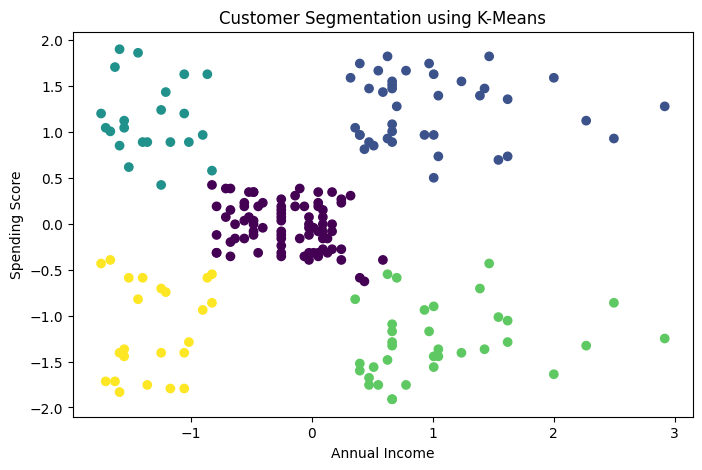


Cluster Centers:
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [3]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv("Mall_Customers.csv")

# Display first 5 rows
print(data.head())

# Select features for clustering
# Change these column names according to your dataset
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create K-Means model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Train the model
kmeans.fit(X_scaled)

# Add cluster labels to the dataset
data['Cluster'] = kmeans.labels_

# Display customers with their cluster
print("\nCustomer Segments:")
print(data.head())

# Plot the clusters
plt.figure(figsize=(8, 5))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans.labels_
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()

# Display cluster centers
print("\nCluster Centers:")
print(kmeans.cluster_centers_)